Data Preprocessing

In [1]:
import pandas as pd
file_path = "/Users/ivan/code/tissues/FantomCAT_robust_genes_vs_traits_pvalue_nonzero_04072021.txt"
# Define the path for the new CSV file
csv_file_path = file_path.replace(".txt", ".csv")

# Read the tab-delimited file
data = pd.read_csv(file_path, sep='\t')

# Save the data as a CSV file
data.to_csv(csv_file_path, index=False)

#csv_file_path

/var/folders/45/nfbllgn100sgd9x52bybyh180000gn/T/ipykernel_66017/4072113985.py:7: DtypeWarning: Columns (2,4,5,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254

In [3]:
# Read the file again to make the second row as the header and skip the first row
m_data = pd.read_csv(file_path, sep='\t', header=1)

# Columns to be dropped
columns_to_drop = ["geneName", "geneClass", "loc", "strongest_DPIClstrID", "chr", "start", "end", "strand", "chr", "chr.1"]

# Drop the specified columns
m_data.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Define the path for the new modified CSV file
modified_csv_file_path = file_path.replace(".txt", "_modified.csv")

# Save the modified data as a CSV file
m_data.to_csv(modified_csv_file_path, index=False)

modified_csv_file_path
m_data.head(5)


,geneID,nervous system,T cell,"CD4-positive, alpha-beta T cell","CD8-positive, alpha-beta T cell",alpha-beta T cell,mesodermal cell,hematopoietic cell,muscle cell,brain,...,respiratory primordium,nephric duct,entire pharyngeal arch endoderm,digestive tract diverticulum,neuroendocrine gland,umbilical blood vessel,cranial skeletal system,meningeal cluster,intervertebral cartilage,axial skeletal system
0,ENSG00000225880,1.060000e-03,3.390000e-10,0.000002,1.0,9.750000e-11,0.545,6.890000e-42,1.0,5.140000e-03,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,ENSG00000240453,1.290000e-03,1.410000e-11,0.000002,1.0,9.690000e-11,0.543,1.050000e-40,1.0,1.850000e-03,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,CATG00000042732,7.140000e-08,1.000000e+00,1.000000,1.0,1.000000e+00,1.000,9.910000e-01,1.0,4.170000e-06,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,ENSG00000223659,1.070000e-08,1.000000e+00,1.000000,1.0,1.000000e+00,1.000,1.000000e+00,1.0,1.330000e-08,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,ENSG00000248527,1.120000e-13,1.000000e+00,1.000000,1.0,1.000000e+00,1.000,9.990000e-01,1.0,7.090000e-16,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
data_all_genes = pd.read_csv("/Users/ivan/code/tissues/FantomCAT_robust_genes_vs_traits_pvalue_nonzero_04072021_modified.csv")
data_selected_gens = pd.read_csv("/Users/ivan/code/Data_bio/Samples_vs_Genes4.csv")
data_all_genes.info
data_selected_gens.info

Create a new dataset for selected genes

In [10]:
# Extract the set of unique geneIDs from data2
unique_geneIDs_data_selected_gens = set(data_selected_gens.columns)

# Filter data_all_genes based on the geneIDs in data2
data3 = data_all_genes[data_all_genes['geneID'].isin(unique_geneIDs_data_selected_gens)]

# Save the new DataFrame to a new CSV file
data3.to_csv('filtered_data3.csv', index=False)

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data3 = pd.read_csv("filtered_data3.csv")
data3.set_index('geneID', inplace=True)
data3.shape


(18207, 347)

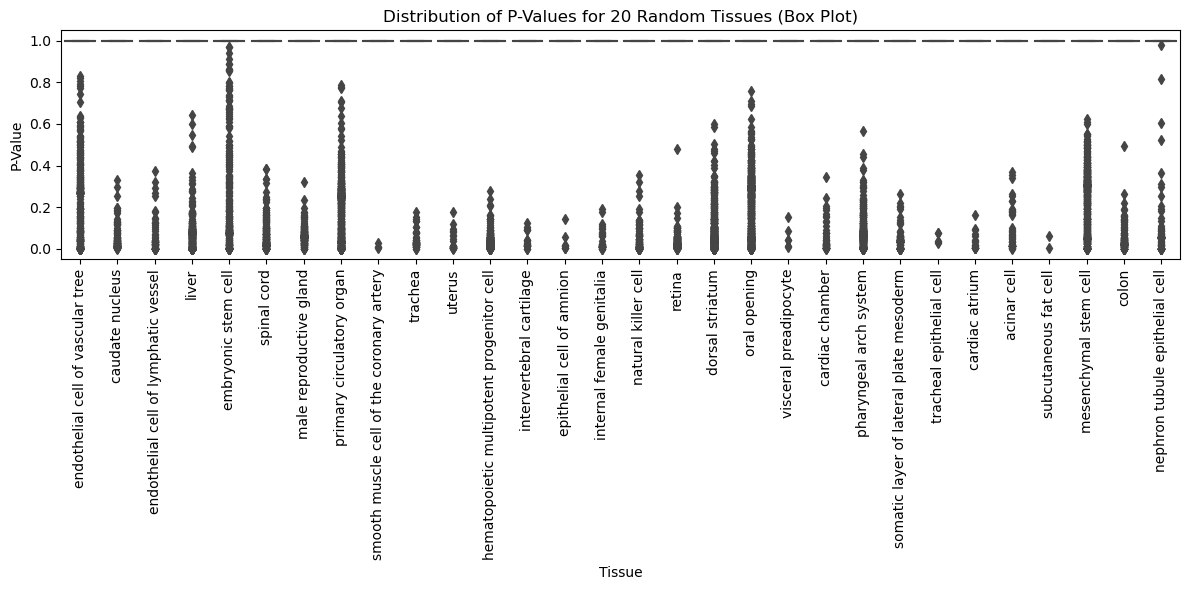

In [2]:

# Selecting 20 random tissues for visualization
selected_tissues = data3.sample(n=30, axis=1)
# Melting the DataFrame for the selected tissues
selected_tissues_melted = selected_tissues.melt(var_name='Tissue', value_name='P_Value')
# Creating a box plot for the selected tissues
plt.figure(figsize=(12, 6))
sns.boxplot(x='Tissue', y='P_Value', data=selected_tissues_melted)
plt.xticks(rotation=90)
plt.xlabel('Tissue')
plt.ylabel('P-Value')
plt.title('Distribution of P-Values for 20 Random Tissues (Box Plot)')
plt.tight_layout()
plt.show()

<Figure size 1600x1200 with 0 Axes>

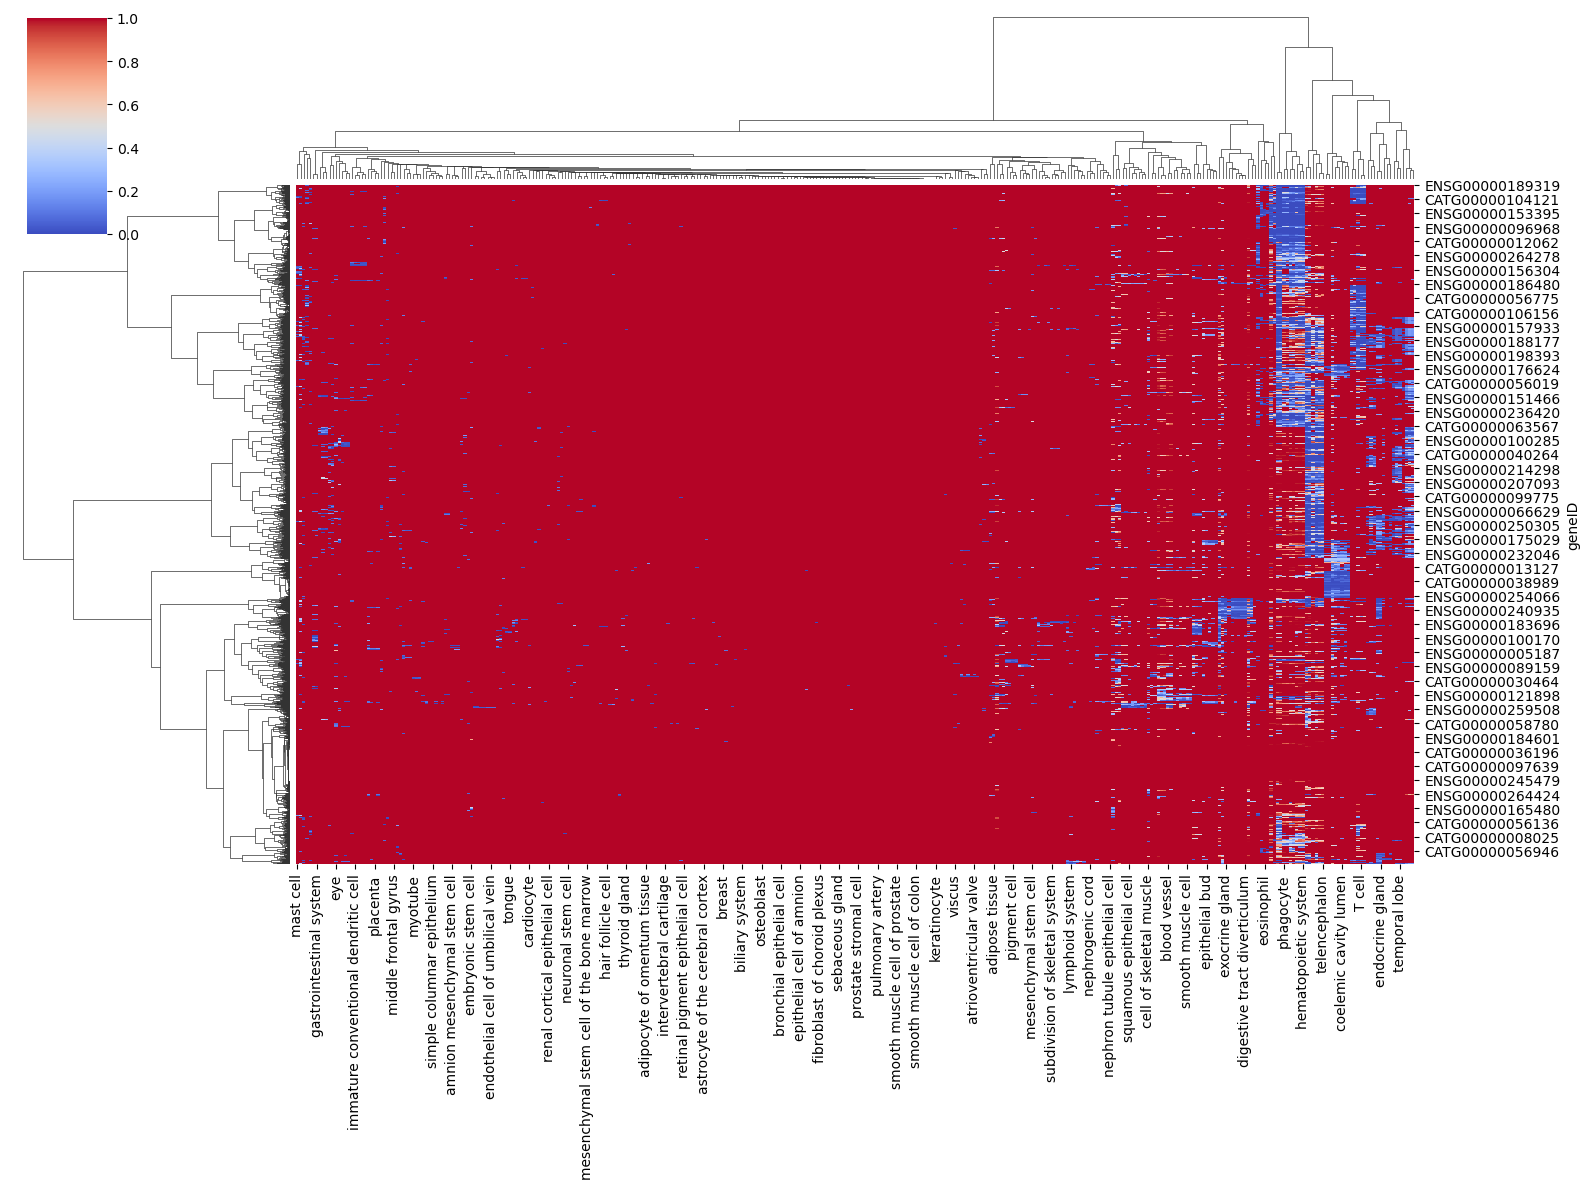

In [10]:
# Importing necessary libraries for clustering and heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Setting the figure size
plt.figure(figsize=(16, 12))

# Creating a heatmap with hierarchical clustering
sns.clustermap(data3, method='ward', cmap='coolwarm', figsize=(16, 12))
#sns.clustermap(numerical_data, method='average', metric='euclidean', cmap='viridis', row_cluster=True, col_cluster=True)
# Displaying the plot
plt.show()

In [23]:
from scipy.cluster.hierarchy import linkage, fcluster



# Transpose the DataFrame to cluster based on columns instead of rows
data3_T = data3.T

# Hierarchical Clustering
Z = linkage(data3_T, method='ward')

#  Cut the Dendrogram to Form Clusters

distance_threshold = 80  # Replace with your desired distance threshold
cluster_labels = fcluster(Z, distance_threshold, criterion='distance')


cluster_mapping = pd.DataFrame({'Original_Column': data3.columns, 'Cluster_Label': cluster_labels})


cluster_p_value_dict = {}


for cluster_label in np.unique(cluster_labels):
    # Extract columns belonging to this cluster
    cluster_columns = cluster_mapping.loc[cluster_mapping['Cluster_Label'] == cluster_label, 'Original_Column']
    
    # Extract p-values from the original DataFrame based on these columns
    cluster_data = data3[cluster_columns]
    
    # Count the number of p-values below the threshold for this cluster
    num_significant_p_values = (cluster_data < 0.05).sum().sum()
    
    cluster_p_value_dict[cluster_label] = num_significant_p_values

# Sort clusters based on the count of significant p-values, in descending order
sorted_clusters = sorted(cluster_p_value_dict.items(), key=lambda x: x[1], reverse=True)

# Extract top 10 clusters with most significant p-values
top_10_clusters = sorted_clusters[:10]

print("Top 10 clusters (Cluster Label, Number of Significant P-Values): ", top_10_clusters)


for cluster_label, _ in top_10_clusters:
    cluster_members = cluster_mapping[cluster_mapping['Cluster_Label'] == cluster_label]['Original_Column'].tolist()
    print(f"Members of Cluster {cluster_label}: {cluster_members}")


Top 10 clusters (Cluster Label, Number of Significant P-Values):  [(4, 30731), (1, 24550), (5, 21927), (7, 10019), (8, 8640), (3, 7985), (6, 7706), (10, 5392), (2, 5173), (9, 3742)]
Members of Cluster 4: ['hematopoietic cell', 'phagocyte', 'monocyte', 'leukocyte', 'myeloid cell', 'myeloid leukocyte', 'hemolymphoid system', 'hematopoietic system', 'immune system']
Members of Cluster 1: ['CD8-positive, alpha-beta T cell', 'muscle cell', 'brainstem', 'striatum', 'parietal lobe', 'dorsal striatum', 'occipital lobe', 'frontal cortex', 'pons', 'spinal cord', 'thalamic complex', 'middle frontal gyrus', 'hippocampal formation', 'locus ceruleus', 'medulla oblongata', 'putamen', 'caudate nucleus', 'astrocyte of the cerebral cortex', 'stem cell', 'hematopoietic stem cell', 'neuronal stem cell', 'common myeloid progenitor', 'myoblast', 'fibroblast', 'osteoblast', 'ciliated epithelial cell', 'blood vessel endothelial cell', 'squamous epithelial cell', 'mesothelial cell', 'epithelial cell of lung', 

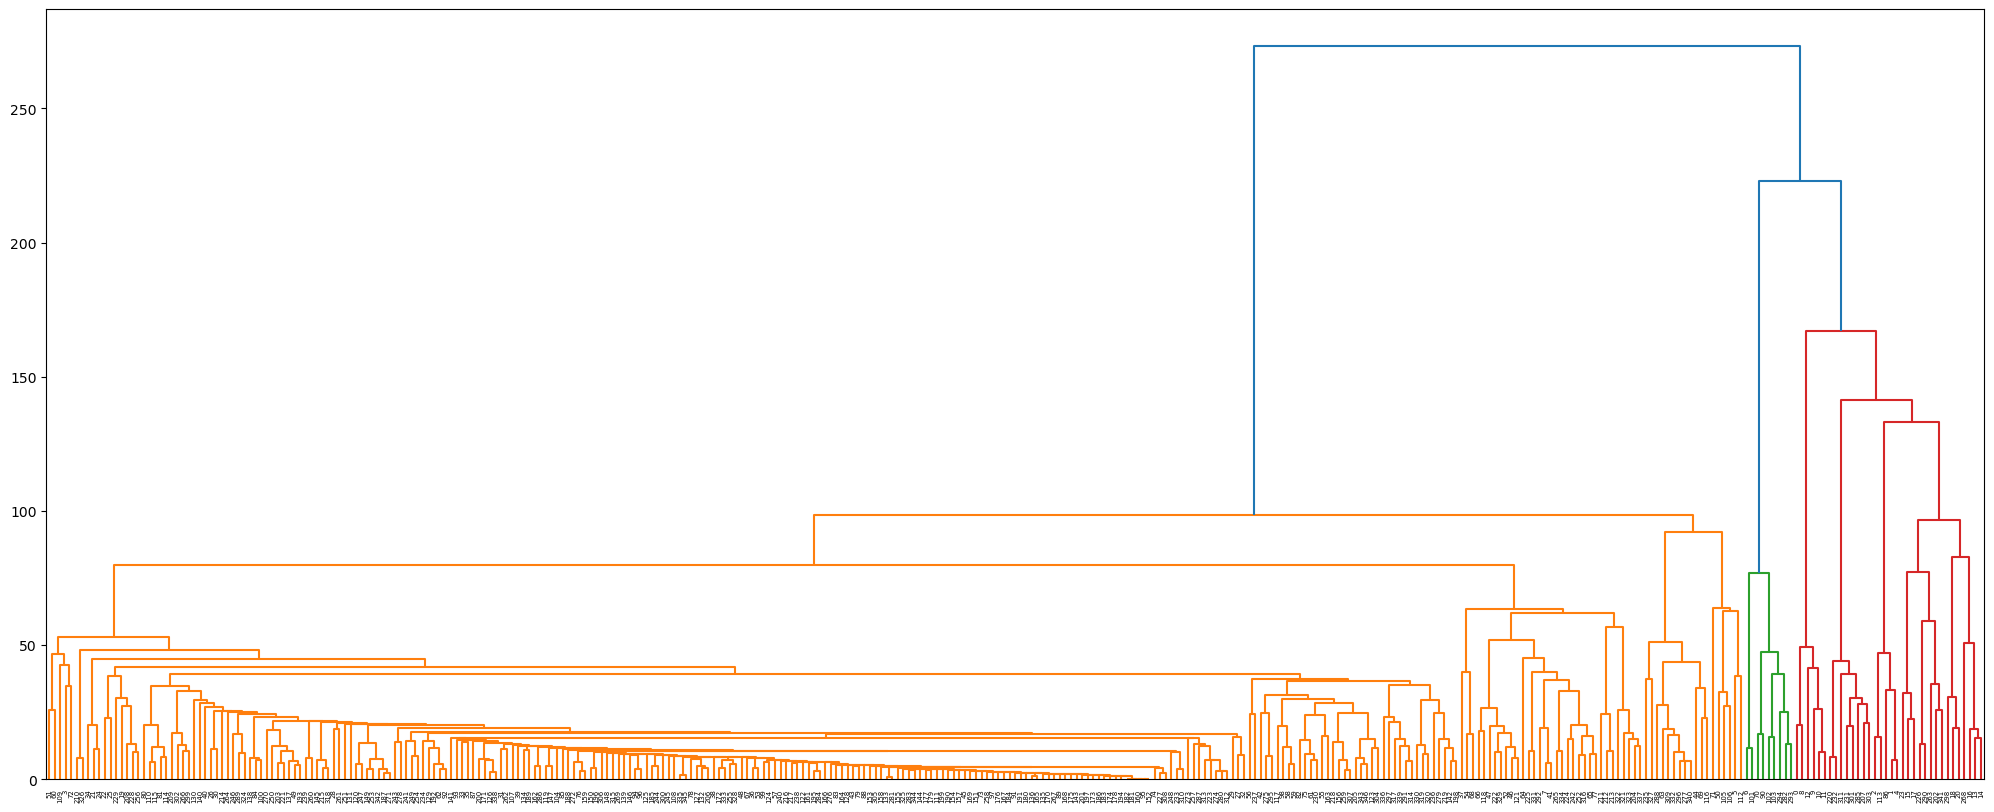

In [24]:
from scipy.cluster.hierarchy import dendrogram
plt.figure(figsize=(25, 10))
dendrogram(Z)
plt.show()

##Density-based clustering

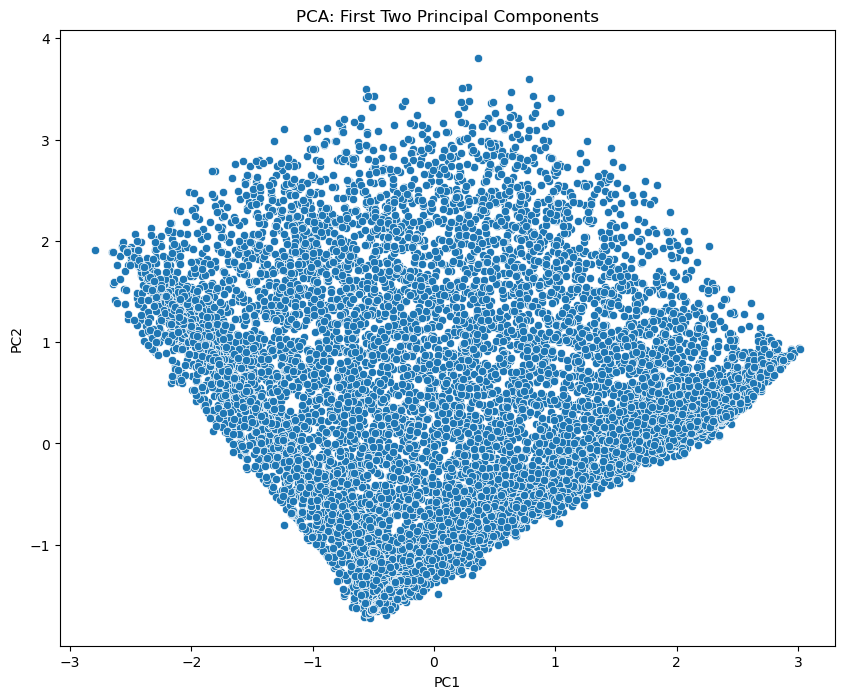

In [4]:
from sklearn.decomposition import PCA


# Perform PCA
pca = PCA(n_components=2)  # Reduce to 2 dimensions
reduced_data = pca.fit_transform(data3)

# Convert to DataFrame for easier plotting
reduced_data_df = pd.DataFrame(reduced_data, columns=['PC1', 'PC2'])

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', data=reduced_data_df)
plt.title('PCA: First Two Principal Components')
plt.show()


In [5]:
from sklearn.cluster import KMeans

# Perform K-Means clustering on the PCA-reduced data
kmeans = KMeans(n_clusters=8, random_state=42)
kmeans_clusters = kmeans.fit_predict(reduced_data)

# Add cluster labels to the reduced data for plotting
reduced_data_df['KMeans_Cluster'] = kmeans_clusters

# Plot the K-Means clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', palette='viridis', data=reduced_data_df, legend="full")
plt.title('K-Means Clustering on PCA-reduced Data')
plt.show()



: 